## Imports

In [108]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cuda


In [109]:
import torch
import torch.nn as nn
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# 1. Define the same UNet model we trained
# -------------------------

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.d1 = ConvBlock(1, 32)
        self.p1 = nn.MaxPool2d(2)

        self.d2 = ConvBlock(32, 64)
        self.p2 = nn.MaxPool2d(2)

        self.d3 = ConvBlock(64, 128)
        self.p3 = nn.MaxPool2d(2)

        self.d4 = ConvBlock(128, 256)
        self.p4 = nn.MaxPool2d(2)

        # Bottleneck
        self.bn = ConvBlock(256, 512)

        # Decoder
        self.u4 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.c4 = ConvBlock(256 + 256, 256)

        self.u3 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.c3 = ConvBlock(128 + 128, 128)

        self.u2 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.c2 = ConvBlock(64 + 64, 64)

        self.u1 = nn.ConvTranspose2d(64, 32, 2, 2)
        self.c1 = ConvBlock(32 + 32, 32)

        self.out = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        d1 = self.d1(x)
        p1 = self.p1(d1)

        d2 = self.d2(p1)
        p2 = self.p2(d2)

        d3 = self.d3(p2)
        p3 = self.p3(d3)

        d4 = self.d4(p3)
        p4 = self.p4(d4)

        bn = self.bn(p4)

        u4 = self.u4(bn)
        c4 = self.c4(torch.cat([u4, d4], dim=1))

        u3 = self.u3(c4)
        c3 = self.c3(torch.cat([u3, d3], dim=1))

        u2 = self.u2(c3)
        c2 = self.c2(torch.cat([u2, d2], dim=1))

        u1 = self.u1(c2)
        c1 = self.c1(torch.cat([u1, d1], dim=1))

        return self.out(c1)

## Corruption Functions - For artificial shadows

In [110]:
def add_gaussian_noise(img, sigma=0.03):
    # img is already a torch tensor
    noise = torch.randn_like(img, dtype=torch.float32) * sigma
    return torch.clamp(img + noise, 0.0, 1.0)


def add_gaussian_blur(img, kernel=5, sigma=1.0):
    # Convert to numpy float32
    img_np = img.squeeze().cpu().numpy().astype(np.float32)

    img_np = cv2.GaussianBlur(img_np, (kernel, kernel), sigma)

    # Back to torch float32
    return torch.tensor(img_np, dtype=torch.float32).unsqueeze(0)


def add_bias_field(img, strength=0.15):
    h, w = img.shape[-2:]

    # Explicit float32 bias
    bias = np.random.randn(h, w).astype(np.float32)
    bias = cv2.GaussianBlur(bias, (0, 0), sigmaX=32)

    bias = bias / (np.max(np.abs(bias)) + 1e-6)
    bias = 1.0 + strength * bias

    img_np = img.squeeze().cpu().numpy().astype(np.float32)
    img_np = img_np * bias
    img_np = np.clip(img_np, 0.0, 1.0)

    return torch.tensor(img_np, dtype=torch.float32).unsqueeze(0)


def corrupt_patch(img):
    # Always keep float32
    img = img.float()

    if torch.rand(1) < 0.7:
        img = add_gaussian_noise(img)

    if torch.rand(1) < 0.5:
        img = add_gaussian_blur(img)

    if torch.rand(1) < 0.5:
        img = add_bias_field(img)

    return img.float()


## Phase-1 Dataset

In [111]:
class Phase1Dataset(Dataset):
    def __init__(self, image_dir, patch_size=128, samples_per_image=50):
        self.image_dir = image_dir
        self.patch_size = patch_size
        self.samples = []

        image_files = sorted([
            f for f in os.listdir(image_dir)
            if f.lower().endswith((".tif", ".png", ".jpg", ".jpeg"))
        ])

        for fname in image_files:
            path = os.path.join(image_dir, fname)
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = img.astype(np.float32) / 255.0
            h, w = img.shape

            for _ in range(samples_per_image):
                y = np.random.randint(0, h - patch_size)
                x = np.random.randint(0, w - patch_size)
                patch = img[y:y+patch_size, x:x+patch_size]
                self.samples.append(patch)

        print(f"Phase 1 patches created: {len(self.samples)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        clean = torch.tensor(self.samples[idx], dtype=torch.float32).unsqueeze(0)
        noisy = corrupt_patch(clean.clone()).float()
        return noisy, clean



## Dataloader

In [112]:
PHASE1_IMAGE_DIR = r"C:\Users\User\OneDrive\Documents\MATLAB\Matlab Data\solder_ball_data"

train_ds = Phase1Dataset(
    PHASE1_IMAGE_DIR,
    patch_size=128,
    samples_per_image=50
)

train_loader = DataLoader(
    train_ds,
    batch_size=8,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)


Phase 1 patches created: 5600


## Train Phase-1

In [113]:
model = UNet().to(device)
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

EPOCHS = 30
model.train()

for epoch in range(1, EPOCHS + 1):
    running_loss = 0

    for inp, tar in tqdm(train_loader, desc=f"Epoch {epoch}"):
        inp, tar = inp.to(device), tar.to(device)

        optimizer.zero_grad()
        out = model(inp)
        loss = criterion(out, tar)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch:02d} | L1 Loss: {running_loss/len(train_loader):.4f}")

torch.save(model.state_dict(), "phase1_geom.pth")
print("✅ Phase 1 complete. Saved: phase1_geom.pth")


Epoch 1: 100%|███████████████████████████████████████████████████████████████████████| 700/700 [01:02<00:00, 11.15it/s]


Epoch 01 | L1 Loss: 0.0503


Epoch 2: 100%|███████████████████████████████████████████████████████████████████████| 700/700 [01:03<00:00, 11.10it/s]


Epoch 02 | L1 Loss: 0.0182


Epoch 3: 100%|███████████████████████████████████████████████████████████████████████| 700/700 [01:02<00:00, 11.22it/s]


...

Epoch 28 | L1 Loss: 0.0167


Epoch 29: 100%|██████████████████████████████████████████████████████████████████████| 700/700 [01:01<00:00, 11.30it/s]


Epoch 29 | L1 Loss: 0.0167


Epoch 30: 100%|██████████████████████████████████████████████████████████████████████| 700/700 [01:01<00:00, 11.38it/s]


Epoch 30 | L1 Loss: 0.0166
✅ Phase 1 complete. Saved: phase1_geom.pth


## Phase-2

In [114]:
model = UNet().to(device)

ckpt = torch.load("phase1_geom.pth", map_location=device)
model.load_state_dict(ckpt)

model.train()
print("✔ Loaded Phase-1 geometric weights")


✔ Loaded Phase-1 geometric weights


C:\Users\User\AppData\Local\Temp\ipykernel_2736\3541667740.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load("phase1_geom.pth", map_location=device)


## Shadow Corruption Functions

In [115]:
import cv2
import torch
import numpy as np

def add_realistic_solder_shadow(img, strength_range=(0.35, 0.65)):
    """
    Create realistic X-ray shadows mimicking solder ball patterns
    """
    H, W = img.shape[-2:]
    device = img.device
    
    # Create localized circular/elliptical shadows
    num_shadows = np.random.randint(1, 4)  # 1-3 shadow regions
    shadow_mask = torch.ones((H, W), device=device, dtype=torch.float32)
    
    for _ in range(num_shadows):
        # Random shadow parameters
        cx = np.random.randint(W//4, 3*W//4)
        cy = np.random.randint(H//4, 3*H//4)
        radius_x = np.random.randint(min(H,W)//6, min(H,W)//3)
        radius_y = radius_x * np.random.uniform(0.7, 1.3)  # Elliptical
        strength = np.random.uniform(*strength_range)
        
        # Create distance map
        y_coords = torch.arange(H, device=device, dtype=torch.float32)
        x_coords = torch.arange(W, device=device, dtype=torch.float32)
        yy, xx = torch.meshgrid(y_coords, x_coords, indexing='ij')
        
        # Elliptical Gaussian shadow
        dist = ((xx - cx) / radius_x)**2 + ((yy - cy) / radius_y)**2
        shadow_region = 1.0 - strength * torch.exp(-dist / 2)
        shadow_region = torch.clamp(shadow_region, 0.25, 1.0)  # Don't make it too dark
        
        shadow_mask *= shadow_region
    
    # Add some directional blur to simulate X-ray scatter
    shadow_np = shadow_mask.cpu().numpy()
    kernel_size = int(min(H, W) * 0.03)
    if kernel_size % 2 == 0:
        kernel_size += 1
    shadow_np = cv2.GaussianBlur(shadow_np, (kernel_size, kernel_size), sigmaX=2.0, sigmaY=1.0)
    shadow_mask = torch.tensor(shadow_np, device=device, dtype=torch.float32)
    
    # Apply shadow
    shadowed = img * shadow_mask.unsqueeze(0)
    
    # Add slight noise (X-ray sensor noise)
    if torch.rand(1) > 0.7:
        shadowed = shadowed + 0.01 * torch.randn_like(shadowed)
    
    return torch.clamp(shadowed, 0, 1)


def corrupt_patch_phase2(img):
    """
    Improved Phase-2 corruption with realistic solder ball shadows
    """
    img = img.float()
    
    # Apply realistic shadow (80% chance)
    if torch.rand(1) > 0.2:
        img = add_realistic_solder_shadow(img)
    
    # Optional: add low-frequency bias (30% chance for variety)
    if torch.rand(1) > 0.7:
        H, W = img.shape[-2:]
        bias = torch.randn(H, W, device=img.device)
        bias = bias / (bias.abs().max() + 1e-6)
        
        # Very strong blur
        k = int(min(H, W) * 0.5)
        if k % 2 == 0:k += 1
        bias_np = cv2.GaussianBlur(bias.cpu().numpy(), (k, k), sigmaX=k/2)
        bias = torch.tensor(bias_np, device=img.device)
        
        img = img * (1.0 + 0.15 * bias.unsqueeze(0))
    
    return torch.clamp(img, 0, 1)


## Phase-2 Dataset

In [116]:
class Phase2Dataset(Dataset):
    def __init__(self, clean_patches, shadows_per_clean=4):
        self.clean_patches = clean_patches
        self.shadows_per_clean = shadows_per_clean

    def __len__(self):
        # each clean patch appears multiple times with different shadows
        return len(self.clean_patches) * self.shadows_per_clean

    def __getitem__(self, idx):
        clean_idx = idx // self.shadows_per_clean

        clean = torch.tensor(
            self.clean_patches[clean_idx],
            dtype=torch.float32
        ).unsqueeze(0)

        shadowed = corrupt_patch_phase2(clean.clone())

        return shadowed, clean


## Training setup with lower learning rate 

In [117]:
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)  # lower LR
EPOCHS = 25


## Helper Function

In [118]:
def gradient_loss(pred, target):
    # Horizontal gradients
    dx_pred = torch.abs(pred[:, :, :, 1:] - pred[:, :, :, :-1])
    dx_tgt  = torch.abs(target[:, :, :, 1:] - target[:, :, :, :-1])

    # Vertical gradients
    dy_pred = torch.abs(pred[:, :, 1:, :] - pred[:, :, :-1, :])
    dy_tgt  = torch.abs(target[:, :, 1:, :] - target[:, :, :-1, :])

    return torch.mean(torch.abs(dx_pred - dx_tgt)) + \
           torch.mean(torch.abs(dy_pred - dy_tgt))


In [121]:
# ============================================
# Phase 2 Dataset & DataLoader Setup
# ============================================

# First, get the clean patches from Phase 1 training set
print("Creating Phase 2 dataset from Phase 1 patches...")

# Extract clean patches (same as Phase 1 used)
PHASE1_IMAGE_DIR = r"C:\Users\User\OneDrive\Documents\MATLAB\Matlab Data\solder_ball_data"
patch_size = 128
samples_per_image = 50

# Collect clean patches
clean_patches = []
image_files = sorted([f for f in os.listdir(PHASE1_IMAGE_DIR) 
                     if f.lower().endswith(('.tif', '.png', '.jpg', '.jpeg'))])

for fname in image_files:
    path = os.path.join(PHASE1_IMAGE_DIR, fname)
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue
    img = img.astype(np.float32) / 255.0
    h, w = img.shape
    
    for _ in range(samples_per_image):
        y = np.random.randint(0, h - patch_size)
        x = np.random.randint(0, w - patch_size)
        patch = img[y:y+patch_size, x:x+patch_size]
        clean_patches.append(patch)

print(f"Phase 2: {len(clean_patches)} clean patches collected")

# Create Phase 2 dataset with shadow corruption
class Phase2Dataset(Dataset):
    def __init__(self, clean_patches, shadows_per_clean=4):
        self.clean_patches = clean_patches
        self.shadows_per_clean = shadows_per_clean
    
    def __len__(self):
        # Each clean patch appears multiple times with different shadows
        return len(self.clean_patches) * self.shadows_per_clean
    
    def __getitem__(self, idx):
        clean_idx = idx // self.shadows_per_clean
        
        clean = torch.tensor(
            self.clean_patches[clean_idx],
            dtype=torch.float32
        ).unsqueeze(0)
        
        # Apply shadow corruption
        shadowed = corrupt_patch_phase2(clean.clone())
        
        return shadowed, clean

# Create dataset and dataloader
train_ds = Phase2Dataset(clean_patches, shadows_per_clean=4)

trainloader = DataLoader(
    train_ds,
    batch_size=8,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

print(f"Phase 2 DataLoader ready: {len(train_ds)} training samples")


Creating Phase 2 dataset from Phase 1 patches...
Phase 2: 5600 clean patches collected
Phase 2 DataLoader ready: 22400 training samples


## Train phase-2

In [133]:
import cv2
import torch
import numpy as np
from tqdm import tqdm

# ============================================
# IMPROVED SHADOW CORRUPTION FUNCTIONS
# ============================================

def add_realistic_solder_shadow(img, strength_range=(0.35, 0.65)):
    """
    Create realistic X-ray shadows mimicking solder ball patterns
    """
    H, W = img.shape[-2:]
    device = img.device
    
    # Create localized circular/elliptical shadows
    num_shadows = np.random.randint(1, 4)  # 1-3 shadow regions
    shadow_mask = torch.ones((H, W), device=device, dtype=torch.float32)
    
    for _ in range(num_shadows):
        # Random shadow parameters
        cx = np.random.randint(W//4, 3*W//4)
        cy = np.random.randint(H//4, 3*H//4)
        radius_x = np.random.randint(min(H,W)//6, min(H,W)//3)
        radius_y = radius_x * np.random.uniform(0.7, 1.3)  # Elliptical
        strength = np.random.uniform(*strength_range)
        
        # Create distance map
        y_coords = torch.arange(H, device=device, dtype=torch.float32)
        x_coords = torch.arange(W, device=device, dtype=torch.float32)
        yy, xx = torch.meshgrid(y_coords, x_coords, indexing='ij')
        
        # Elliptical Gaussian shadow
        dist = ((xx - cx) / radius_x)**2 + ((yy - cy) / radius_y)**2
        shadow_region = 1.0 - strength * torch.exp(-dist / 2)
        shadow_region = torch.clamp(shadow_region, 0.25, 1.0)
        
        shadow_mask *= shadow_region
    
    # Add directional blur to simulate X-ray scatter
    shadow_np = shadow_mask.cpu().numpy()
    kernel_size = int(min(H, W) * 0.03)
    if kernel_size % 2 == 0:
        kernel_size += 1
    shadow_np = cv2.GaussianBlur(shadow_np, (kernel_size, kernel_size), sigmaX=2.0, sigmaY=1.0)
    shadow_mask = torch.tensor(shadow_np, device=device, dtype=torch.float32)
    
    # Apply shadow
    shadowed = img * shadow_mask.unsqueeze(0)
    
    # Add slight noise (X-ray sensor noise)
    if torch.rand(1) > 0.7:
        shadowed = shadowed + 0.01 * torch.randn_like(shadowed)
    
    return torch.clamp(shadowed, 0, 1)


def corrupt_patch_phase2(img):
    """
    Improved Phase-2 corruption with realistic solder ball shadows
    """
    img = img.float()
    
    # Apply realistic shadow (80% chance)
    if torch.rand(1) > 0.2:
        img = add_realistic_solder_shadow(img)
    
    # Optional: add low-frequency bias (30% chance for variety)
    if torch.rand(1) > 0.7:
        H, W = img.shape[-2:]
        bias = torch.randn(H, W, device=img.device)
        bias = bias / (bias.abs().max() + 1e-6)
        
        # Very strong blur
        k = int(min(H, W) * 0.5)
        if k % 2 == 0:
            k += 1
        bias_np = cv2.GaussianBlur(bias.cpu().numpy(), (k, k), sigmaX=k/2)
        bias = torch.tensor(bias_np, device=img.device)
        
        img = img * (1.0 + 0.15 * bias.unsqueeze(0))
    
    return torch.clamp(img, 0, 1)


# ============================================
# LOSS FUNCTIONS
# ============================================

criterion = nn.L1Loss()

def gradient_loss(pred, target):
    """Horizontal and vertical gradients"""
    # Horizontal gradients
    dx_pred = torch.abs(pred[:, :, :, 1:] - pred[:, :, :, :-1])
    dx_tgt = torch.abs(target[:, :, :, 1:] - target[:, :, :, :-1])
    
    # Vertical gradients
    dy_pred = torch.abs(pred[:, :, 1:, :] - pred[:, :, :-1, :])
    dy_tgt = torch.abs(target[:, :, 1:, :] - target[:, :, :-1, :])
    
    return torch.mean(torch.abs(dx_pred - dx_tgt)) + torch.mean(torch.abs(dy_pred - dy_tgt))

def edge_loss(pred, target):
    """Edge-aware loss for structural preservation"""
    # Horizontal edges
    pred_edges_h = torch.abs(pred[:, :, :, 1:] - pred[:, :, :, :-1])
    target_edges_h = torch.abs(target[:, :, :, 1:] - target[:, :, :, :-1])
    
    # Vertical edges
    pred_edges_v = torch.abs(pred[:, :, 1:, :] - pred[:, :, :-1, :])
    target_edges_v = torch.abs(target[:, :, 1:, :] - target[:, :, :-1, :])
    
    # Average both directions
    loss_h = nn.functional.l1_loss(pred_edges_h, target_edges_h)
    loss_v = nn.functional.l1_loss(pred_edges_v, target_edges_v)
    
    return (loss_h + loss_v) / 2.0


# ============================================
# TRAINING LOOP
# ============================================

optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)
EPOCHS = 25

model.train()

print("=" * 70)
print("Phase 2 Training: Shadow Pattern Learning (IMPROVED)")
print("=" * 70)
print("Using realistic solder ball shadow generation")
print()

for epoch in range(1, EPOCHS + 1):
    running_loss = 0.0
    running_l1 = 0.0
    running_grad = 0.0
    running_edge = 0.0
    
    pbar = tqdm(trainloader, desc=f"Epoch {epoch:02d}/{EPOCHS}")
    
    for inp, tar in pbar:
        inp = inp.to(device).float()
        tar = tar.to(device).float()
        
        optimizer.zero_grad()
        out = model(inp)
        
        # Combined loss: L1 + Gradient + Edge
        l1 = criterion(out, tar)
        grad = gradient_loss(out, tar)
        edge = edge_loss(out, tar)
        
        loss = 0.5 * l1 + 0.3 * grad + 0.2 * edge
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        running_l1 += l1.item()
        running_grad += grad.item()
        running_edge += edge.item()
        
        # Show all loss components in progress bar
        pbar.set_postfix({
            'Total': f'{loss.item():.4f}',
            'L1': f'{l1.item():.4f}',
            'Grad': f'{grad.item():.5f}',
            'Edge': f'{edge.item():.5f}'
        })
    
    # Calculate epoch averages
    epoch_loss = running_loss / len(trainloader)
    epoch_l1 = running_l1 / len(trainloader)
    epoch_grad = running_grad / len(trainloader)
    epoch_edge = running_edge / len(trainloader)
    
    print(f"Epoch {epoch:02d} | Loss: {epoch_loss:.4f} | "
          f"L1: {epoch_l1:.4f} | Grad: {epoch_grad:.5f} | Edge: {epoch_edge:.5f}")

# Save Phase 2 model
torch.save(model.state_dict(), 'phase2_shadow.pth')
print()
print("=" * 70)
print("✓ Phase 2 complete. Saved 'phase2_shadow.pth'")
print("=" * 70)


Phase 2 Training: Shadow Pattern Learning (IMPROVED)
Using realistic solder ball shadow generation



Epoch 01/25: 100%|████████████| 2800/2800 [04:21<00:00, 10.71it/s, Total=0.0073, L1=0.0118, Grad=0.00358, Edge=0.00179]


Epoch 01 | Loss: 0.0075 | L1: 0.0110 | Grad: 0.00497 | Edge: 0.00248


Epoch 02/25: 100%|████████████| 2800/2800 [04:12<00:00, 11.08it/s, Total=0.0047, L1=0.0083, Grad=0.00140, Edge=0.00070]


Epoch 02 | Loss: 0.0074 | L1: 0.0108 | Grad: 0.00489 | Edge: 0.00244


...

Epoch 23 | Loss: 0.0062 | L1: 0.0087 | Grad: 0.00453 | Edge: 0.00226


Epoch 24/25: 100%|████████████| 2800/2800 [04:04<00:00, 11.44it/s, Total=0.0053, L1=0.0084, Grad=0.00282, Edge=0.00141]


Epoch 24 | Loss: 0.0062 | L1: 0.0087 | Grad: 0.00455 | Edge: 0.00228


Epoch 25/25: 100%|████████████| 2800/2800 [04:01<00:00, 11.57it/s, Total=0.0057, L1=0.0079, Grad=0.00444, Edge=0.00222]


Epoch 25 | Loss: 0.0061 | L1: 0.0086 | Grad: 0.00446 | Edge: 0.00223

✓ Phase 2 complete. Saved 'phase2_shadow.pth'


In [134]:
torch.save(model.state_dict(), "phase2_shadow.pth")
print("Phase 2 complete. Saved: phase2_shadow.pth")


Phase 2 complete. Saved: phase2_shadow.pth


# Phase - 3 - Final Model 

### Imports and device 

In [135]:
import os
import cv2
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from math import log10

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cuda


## U-Net Model

In [136]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.d1 = ConvBlock(1, 32)
        self.p1 = nn.MaxPool2d(2)

        self.d2 = ConvBlock(32, 64)
        self.p2 = nn.MaxPool2d(2)

        self.d3 = ConvBlock(64, 128)
        self.p3 = nn.MaxPool2d(2)

        self.d4 = ConvBlock(128, 256)
        self.p4 = nn.MaxPool2d(2)

        self.bn = ConvBlock(256, 512)

        self.u4 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.c4 = ConvBlock(512, 256)

        self.u3 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.c3 = ConvBlock(256, 128)

        self.u2 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.c2 = ConvBlock(128, 64)

        self.u1 = nn.ConvTranspose2d(64, 32, 2, 2)
        self.c1 = ConvBlock(64, 32)

        self.out = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        d1 = self.d1(x)
        d2 = self.d2(self.p1(d1))
        d3 = self.d3(self.p2(d2))
        d4 = self.d4(self.p3(d3))
        bn = self.bn(self.p4(d4))

        u4 = self.c4(torch.cat([self.u4(bn), d4], dim=1))
        u3 = self.c3(torch.cat([self.u3(u4), d3], dim=1))
        u2 = self.c2(torch.cat([self.u2(u3), d2], dim=1))
        u1 = self.c1(torch.cat([self.u1(u2), d1], dim=1))

        return self.out(u1)


##  Load phase-2 weights 

In [142]:
import torch
import torch.nn as nn

# Reinitialize model
model = UNet().to(device)

# Load the improved Phase 2 weights
ckpt = torch.load('phase2_shadow.pth', map_location=device)

# Key remapping (in case conv/block mismatch)
new_ckpt = {}
for k, v in ckpt.items():
    new_k = k.replace('conv', 'block')
    new_ckpt[new_k] = v

model.load_state_dict(new_ckpt, strict=False)
model.train()

print("✓ Loaded improved Phase-2 shadow-aware weights")
print("Ready for Phase 3 training!")


✓ Loaded improved Phase-2 shadow-aware weights
Ready for Phase 3 training!


C:\Users\User\AppData\Local\Temp\ipykernel_2736\2531875984.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load('phase2_shadow.pth', map_location=device)


## PatchDataset

In [146]:
# class PatchDataset(Dataset):
#     def __init__(self, root_dir, split, augment=False):
#         self.augment = augment
#         self.input_dir = os.path.join(root_dir, split, "input")
#         self.target_dir = os.path.join(root_dir, split, "target")
#         self.files = sorted(os.listdir(self.input_dir))

#     def __len__(self):
#         return len(self.files)

#     def __getitem__(self, idx):
#         fname = self.files[idx]

#         inp = cv2.imread(os.path.join(self.input_dir, fname), 0).astype(np.float32) / 255.0
#         tar = cv2.imread(os.path.join(self.target_dir, fname), 0).astype(np.float32) / 255.0

#         inp = torch.tensor(inp, dtype=torch.float32).unsqueeze(0)
#         tar = torch.tensor(tar, dtype=torch.float32).unsqueeze(0)

#         if self.augment:
#             if torch.rand(1) < 0.5:
#                 inp = TF.hflip(inp)
#                 tar = TF.hflip(tar)
#             if torch.rand(1) < 0.5:
#                 inp = TF.vflip(inp)
#                 tar = TF.vflip(tar)
from torch.utils.data import Dataset, DataLoader
import os

class PatchDataset(Dataset):
    def __init__(self, root_dir, split, augment=False):
        self.augment = augment
        self.input_dir = os.path.join(root_dir, split, 'input')
        self.target_dir = os.path.join(root_dir, split, 'target')
        self.files = sorted(os.listdir(self.input_dir))
    
    def __len__(self):
        return len(self.files)
    
    def __getitem__(self, idx):
        fname = self.files[idx]
        
        inp = cv2.imread(os.path.join(self.input_dir, fname), 0).astype(np.float32) / 255.0
        tar = cv2.imread(os.path.join(self.target_dir, fname), 0).astype(np.float32) / 255.0
        
        inp = torch.tensor(inp, dtype=torch.float32).unsqueeze(0)
        tar = torch.tensor(tar, dtype=torch.float32).unsqueeze(0)
        
        if self.augment:
            if torch.rand(1) > 0.5:
                inp = TF.hflip(inp)
                tar = TF.hflip(tar)
            if torch.rand(1) > 0.5:
                inp = TF.vflip(inp)
                tar = TF.vflip(tar)
        
        return inp, tar

# Create Phase 3 datasets
train_ds = PatchDataset(r"C:\Users\User\OneDrive\Documents\Shadow Removal\Shadow_Removal\dataset_v2", "train", augment=True)
val_ds = PatchDataset(r"C:\Users\User\OneDrive\Documents\Shadow Removal\Shadow_Removal\dataset_v2", "val", augment=False)

# Create Phase 3 dataloaders
trainloader = DataLoader(train_ds, batch_size=2, shuffle=True, num_workers=0)
valloader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=0)

print(f"✓ Phase 3 Data Ready: Train={len(train_ds)}, Val={len(val_ds)}")




✓ Phase 3 Data Ready: Train=14, Val=3


## Dataloaders

In [139]:
train_ds = PatchDataset(r"C:\Users\User\OneDrive\Documents\Shadow Removal\Shadow_Removal\dataset_v2", "train", augment=True)
val_ds   = PatchDataset(r"C:\Users\User\OneDrive\Documents\Shadow Removal\Shadow_Removal\dataset_v2", "val", augment=False)

train_loader = DataLoader(
    train_ds,
    batch_size=2,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_ds,
    batch_size=1,
    shuffle=False,
    num_workers=0
)

print("Train:", len(train_ds), " Val:", len(val_ds))


Train: 14  Val: 3


## Loss Optimizer Metrics

In [140]:
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
EPOCHS = 25

def psnr(pred, gt):
    mse = torch.mean((pred - gt) ** 2).item()
    if mse == 0:
        return 100
    return 10 * log10(1 / mse)

def compute_ssim(pred, gt):
    p = pred.squeeze().cpu().numpy()
    g = gt.squeeze().cpu().numpy()
    return ssim(p, g, data_range=1)


## Training Loop

In [147]:
from skimage.metrics import structural_similarity as ssim
from math import log10
from tqdm import tqdm
import torchvision.transforms.functional as TF

# ============================================
# SETUP: Loss, Optimizer, Metrics
# ============================================

criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
EPOCHS = 25

def psnr(pred, gt):
    mse = torch.mean((pred - gt) ** 2).item()
    if mse == 0:
        return 100
    return 10 * log10(1 / mse)

def compute_ssim(pred, gt):
    p = pred.squeeze().cpu().numpy()
    g = gt.squeeze().cpu().numpy()
    return ssim(p, g, data_range=1)

def edge_loss(pred, target):
    """Edge preservation loss"""
    pred_edges_h = torch.abs(pred[:, :, :, 1:] - pred[:, :, :, :-1])
    target_edges_h = torch.abs(target[:, :, :, 1:] - target[:, :, :, :-1])
    pred_edges_v = torch.abs(pred[:, :, 1:, :] - pred[:, :, :-1, :])
    target_edges_v = torch.abs(target[:, :, 1:, :] - target[:, :, :-1, :])
    loss_h = nn.functional.l1_loss(pred_edges_h, target_edges_h)
    loss_v = nn.functional.l1_loss(pred_edges_v, target_edges_v)
    return (loss_h + loss_v) / 2.0

# ============================================
# TRAINING LOOP
# ============================================

best_val = 999

print("=" * 70)
print("Phase 3 Training: Real TRI Data Fine-tuning")
print("=" * 70)
print()

for epoch in range(1, EPOCHS + 1):
    # Training
    model.train()
    train_loss = 0
    
    pbar = tqdm(trainloader, desc=f"Epoch {epoch:02d}/{EPOCHS}")
    for inp, tar in pbar:
        inp = inp.to(device)
        tar = tar.to(device)
        
        optimizer.zero_grad()
        out = model(inp)
        
        l1 = criterion(out, tar)
        edge = edge_loss(out, tar)
        loss = 0.7 * l1 + 0.3 * edge
        
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        pbar.set_postfix({'L1': f'{l1.item():.4f}', 'Edge': f'{edge.item():.4f}'})
    
    train_loss /= len(trainloader)
    
    # Validation
    model.eval()
    val_loss = 0
    val_psnr = 0
    val_ssim = 0
    
    with torch.no_grad():
        for inp, tar in valloader:
            inp = inp.to(device)
            tar = tar.to(device)
            out = model(inp)
            
            l1 = criterion(out, tar)
            edge = edge_loss(out, tar)
            loss = 0.7 * l1 + 0.3 * edge
            
            val_loss += loss.item()
            val_psnr += psnr(out, tar)
            val_ssim += compute_ssim(out, tar)
    
    val_loss /= len(valloader)
    val_psnr /= len(valloader)
    val_ssim /= len(valloader)
    
    print(f"Epoch {epoch:02d} | Train: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | PSNR: {val_psnr:.2f} | SSIM: {val_ssim:.4f}")
    
    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), 'final_tri_model.pth')
        print("  ✓ Saved best model")

print()
print("=" * 70)
print("✓ Phase 3 complete. Best model saved as 'final_tri_model.pth'")
print("=" * 70)


Phase 3 Training: Real TRI Data Fine-tuning



Epoch 01/25: 100%|███████████████████████████████████████████████| 7/7 [00:00<00:00, 12.65it/s, L1=0.1194, Edge=0.0323]


Epoch 01 | Train: 0.1051 | Val Loss: 0.1027 | PSNR: 15.28 | SSIM: 0.2541
  ✓ Saved best model


Epoch 02/25: 100%|███████████████████████████████████████████████| 7/7 [00:00<00:00, 28.88it/s, L1=0.1135, Edge=0.0353]


Epoch 02 | Train: 0.1046 | Val Loss: 0.1022 | PSNR: 15.30 | SSIM: 0.2568
  ✓ Saved best model


...

Epoch 23 | Train: 0.0990 | Val Loss: 0.0958 | PSNR: 15.74 | SSIM: 0.3062
  ✓ Saved best model


Epoch 24/25: 100%|███████████████████████████████████████████████| 7/7 [00:00<00:00, 29.85it/s, L1=0.1041, Edge=0.0330]


Epoch 24 | Train: 0.0985 | Val Loss: 0.0957 | PSNR: 15.76 | SSIM: 0.3073
  ✓ Saved best model


Epoch 25/25: 100%|███████████████████████████████████████████████| 7/7 [00:00<00:00, 28.03it/s, L1=0.1263, Edge=0.0310]


Epoch 25 | Train: 0.0987 | Val Loss: 0.0956 | PSNR: 15.77 | SSIM: 0.3078
  ✓ Saved best model

✓ Phase 3 complete. Best model saved as 'final_tri_model.pth'


## Run the final model 

In [148]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

device = "cuda" if torch.cuda.is_available() else "cpu"

model = UNet().to(device)

ckpt = torch.load("final_tri_model.pth", map_location=device)

# remap keys if needed (conv → block)
new_ckpt = {k.replace("conv", "block"): v for k, v in ckpt.items()}
model.load_state_dict(new_ckpt, strict=False)

model.eval()
print("✔ Final TRI model loaded")


✔ Final TRI model loaded


C:\Users\User\AppData\Local\Temp\ipykernel_2736\3608308115.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load("final_tri_model.pth", map_location=device)

In [149]:
def run_unet_on_full_image(model, img_path, patch_size=128, overlap=64):
    """
    Fixed sliding window inference with Gaussian-weighted blending
    """
    img = cv2.imread(img_path, 0)
    h, w = img.shape
    img_f = img.astype(np.float32) / 255.0
    
    # Create Gaussian weight map for smooth blending
    def gaussian_weight_map(size):
        """Create 2D Gaussian weight map centered at patch"""
        sigma = size / 4.0
        x = np.arange(size, dtype=np.float32)
        y = np.arange(size, dtype=np.float32)
        xx, yy = np.meshgrid(x - size/2, y - size/2)
        weight = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
        return weight / weight.max()
    
    weight_template = gaussian_weight_map(patch_size)
    
    # Initialize output accumulator and weight sum
    out = np.zeros((h, w), dtype=np.float32)
    weight_sum = np.zeros((h, w), dtype=np.float32)
    
    step = patch_size - overlap
    
    # Sliding window with weighted accumulation
    for i in range(0, h - patch_size + 1, step):
        for j in range(0, w - patch_size + 1, step):
            patch = img_f[i:i+patch_size, j:j+patch_size]
            patch_t = torch.tensor(patch).unsqueeze(0).unsqueeze(0).to(device)
            
            with torch.no_grad():
                pred = model(patch_t).cpu().squeeze().numpy()
            
            # Weighted accumulation
            out[i:i+patch_size, j:j+patch_size] += pred * weight_template
            weight_sum[i:i+patch_size, j:j+patch_size] += weight_template
    
    # Handle edges that weren't covered by sliding window
    # Add edge patches if needed
    if h % step != 0 or w % step != 0:
        # Bottom edge
        if h - patch_size > 0:
            i = h - patch_size
            for j in range(0, w - patch_size + 1, step):
                patch = img_f[i:i+patch_size, j:j+patch_size]
                patch_t = torch.tensor(patch).unsqueeze(0).unsqueeze(0).to(device)
                with torch.no_grad():
                    pred = model(patch_t).cpu().squeeze().numpy()
                out[i:i+patch_size, j:j+patch_size] += pred * weight_template
                weight_sum[i:i+patch_size, j:j+patch_size] += weight_template
        
        # Right edge
        if w - patch_size > 0:
            j = w - patch_size
            for i in range(0, h - patch_size + 1, step):
                patch = img_f[i:i+patch_size, j:j+patch_size]
                patch_t = torch.tensor(patch).unsqueeze(0).unsqueeze(0).to(device)
                with torch.no_grad():
                    pred = model(patch_t).cpu().squeeze().numpy()
                out[i:i+patch_size, j:j+patch_size] += pred * weight_template
                weight_sum[i:i+patch_size, j:j+patch_size] += weight_template
        
        # Bottom-right corner
        if h - patch_size > 0 and w - patch_size > 0:
            i, j = h - patch_size, w - patch_size
            patch = img_f[i:i+patch_size, j:j+patch_size]
            patch_t = torch.tensor(patch).unsqueeze(0).unsqueeze(0).to(device)
            with torch.no_grad():
                pred = model(patch_t).cpu().squeeze().numpy()
            out[i:i+patch_size, j:j+patch_size] += pred * weight_template
            weight_sum[i:i+patch_size, j:j+patch_size] += weight_template
    
    # Normalize by weight sum (avoid division by zero)
    weight_sum = np.maximum(weight_sum, 1e-8)
    out = out / weight_sum
    
    # Convert back to uint8
    out = np.clip(out * 255, 0, 255).astype(np.uint8)
    
    return img, out


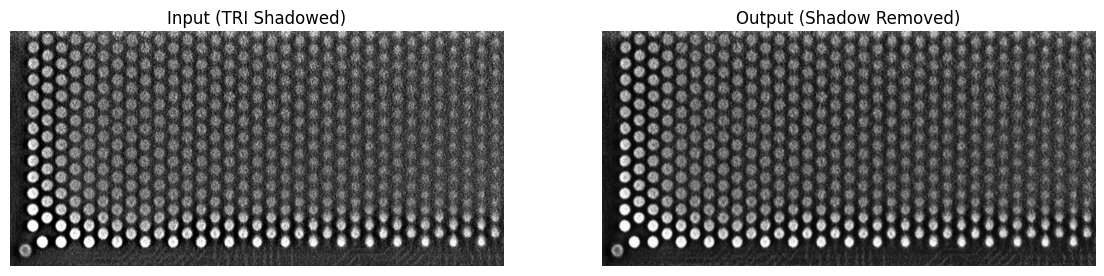

Saved: image1_final.jpeg


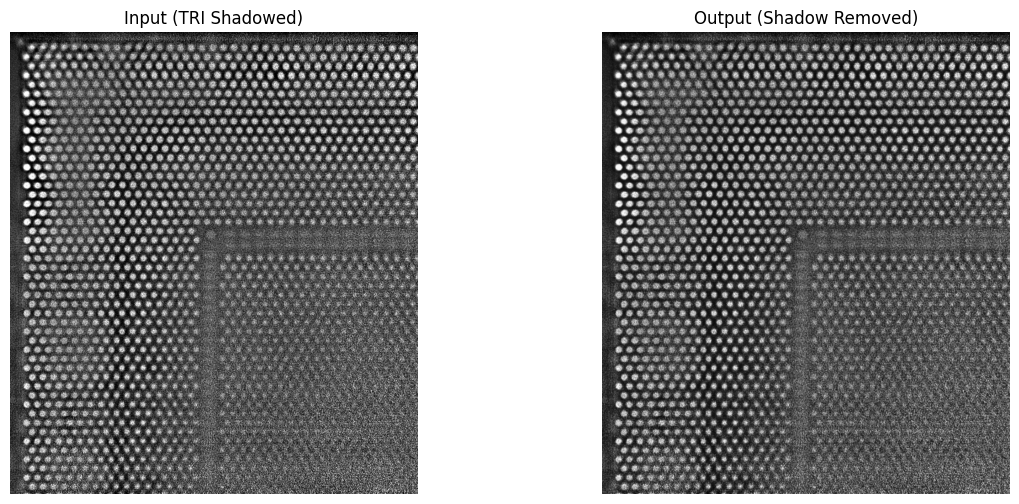

Saved: image2_final.bmp


In [150]:
tri_images = [
    r"C:\Users\User\OneDrive\Documents\Shadow Removal\Shadow_Removal\image1.jpeg",
    r"C:\Users\User\OneDrive\Documents\Shadow Removal\Shadow_Removal\image2.bmp",

]

for img_path in tri_images:
    inp, out = run_unet_on_full_image(model, img_path)

    plt.figure(figsize=(14,6))
    plt.subplot(1,2,1)
    plt.title("Input (TRI Shadowed)")
    plt.imshow(inp, cmap="gray")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title("Output (Shadow Removed)")
    plt.imshow(out, cmap="gray")
    plt.axis("off")

    plt.show()

    save_name = os.path.basename(img_path).replace(".", "_final.")
    cv2.imwrite(save_name, out)
    print("Saved:", save_name)
